# UTILIZZO API DI SPOTIFY
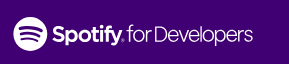

Per utilizzare le API di Spotify, è necessario seguire una serie di passaggi:

### 1. **Creare un Account Spotify Developer**
   - Vai al sito ufficiale per gli sviluppatori di Spotify: [Spotify Developer Dashboard](https://developer.spotify.com/dashboard/applications).
   - Se non hai già un account, crea un account Spotify o accedi con un account esistente.
   
### 2. **Creare una Nuova Applicazione**
   - Una volta effettuato l'accesso al [Dashboard degli sviluppatori di Spotify](https://developer.spotify.com/dashboard/applications), clicca su **"Create an App"**.
   - Compila i dettagli necessari per la tua applicazione:
     - **Nome dell'Applicazione**: Un nome unico per la tua app.
     - **Descrizione**: Una breve descrizione di cosa farà la tua applicazione.
     - **URL di Reindirizzamento (Redirect URI)**: Una URL che Spotify userà per inviare l'utente dopo che ha completato il login. È necessario configurare un URL di reindirizzamento per la gestione dell'autenticazione. Per lo sviluppo in ambiente locale puoi usare: http://127.0.0.1:8000/callback
     - **Termini e Condizioni**: Accetta i termini e le condizioni di utilizzo delle API di Spotify.
   - Clicca su **"Create"** per completare la creazione dell'app.

### 3. **Ottenere le Credenziali dell'Applicazione**
   - Una volta creata l'app, verranno generati un **Client ID** e un **Client Secret**. Questi sono importanti per autenticarti con le API di Spotify.
   - Salva questi valori in un posto sicuro, poiché li utilizzerai per fare richieste alle API.

### 4. **Autenticazione con Spotify**
   Le API di Spotify utilizzano il flusso di autenticazione OAuth 2.0. Puoi scegliere tra due modalità di autenticazione principali:
   - **Autenticazione di tipo Client Credentials Flow**: Consente di ottenere un accesso limitato solo alle informazioni pubbliche di Spotify.
   - **Autenticazione di tipo Authorization Code Flow**: Consente di ottenere l'accesso a dati dell'utente, come playlist, brani salvati, ecc. Questo è il flusso più comune quando si desidera interagire con i dati dell'utente.

#### Esempio di flusso di autenticazione (Authorization Code Flow):
1. **Richiedere l'autenticazione dell'utente**:
   - Fai una richiesta all'endpoint `/authorize` di Spotify, includendo il tuo Client ID, Redirect URI e le autorizzazioni richieste.
   - L'utente verrà reindirizzato alla pagina di login di Spotify e, se accetta, verrà reindirizzato all'URL che hai specificato come Redirect URI.
   
2. **Scambiare il codice di autorizzazione per un token di accesso**:
   - Una volta che l'utente è autenticato, Spotify ti invierà un **Authorization Code** al tuo Redirect URI.
   - Scambia questo codice con un **Access Token** tramite una richiesta HTTP POST all'endpoint `/api/token` di Spotify.
   
3. **Utilizzare il token di accesso**:
   - Una volta ottenuto l'Access Token, puoi usarlo per fare richieste autorizzate alle API di Spotify a nome dell'utente.




https://developer.spotify.com/documentation/web-api

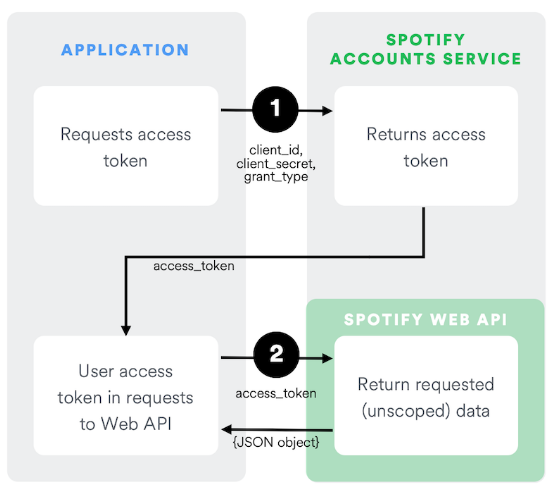

### FASE 1 : OTTENERE IL TOKEN DI ACCESSO

In [1]:
import requests
from urllib.parse import urlencode

# Credenziali dell'applicazione
client_id = '4fa9b374dd4f4a7cb15aca44d8a5aa1e' #qui devi mettere i tuoi dati
client_secret = 'a2293b5361614c4f90481d1c7a762dab' #qui devi mettere i tuoi dati
redirect_uri = 'http://127.0.0.1:8000/callback'  # Assicurati di configurare correttamente questo URI nel dashboard dell'applicazione

# Costruisci l'URL di autorizzazione
authorize_url = 'https://accounts.spotify.com/authorize'
params = {
    'client_id': client_id,
    'response_type': 'code',
    'redirect_uri': redirect_uri,
    'scope': 'user-read-private user-read-email user-read-recently-played '  # Specifica l'ambito delle autorizzazioni richieste (grant_type)
}

# Reindirizza l'utente alla pagina di autorizzazione di Spotify
authorization_redirect_url = authorize_url + '?' + urlencode(params)
print("Vai al seguente URL per autorizzare l'applicazione:",authorization_redirect_url)


# Gestisci il reindirizzamento e ottieni il codice di autorizzazione
authorization_response = input("Inserisci l'URL di reindirizzamento completo dopo aver autorizzato l'applicazione: ")
authorization_code = authorization_response.split('code=')[1]

# Scambia il codice di autorizzazione per un token di accesso
token_url = 'https://accounts.spotify.com/api/token'
token_params = {
    'grant_type': 'authorization_code',
    'code': authorization_code,
    'redirect_uri': redirect_uri,
    'client_id': client_id,
    'client_secret': client_secret,
}
try:
    response = requests.post(token_url, data=token_params)
    if response.status_code == 200:
        access_token = response.json()['access_token']
        print("Token di accesso ottenuto con successo:")
        print(access_token)
except Exception as e:
   print("Errore durante la richiesta:", e)


Vai al seguente URL per autorizzare l'applicazione: https://accounts.spotify.com/authorize?client_id=4fa9b374dd4f4a7cb15aca44d8a5aa1e&response_type=code&redirect_uri=http%3A%2F%2F127.0.0.1%3A8000%2Fcallback&scope=user-read-private+user-read-email+user-read-recently-played+
Inserisci l'URL di reindirizzamento completo dopo aver autorizzato l'applicazione: http://127.0.0.1:8000/callback?code=AQB1TjmJmFLZ3hUHEW2N_TtkhWAmQ1hmEeBe6m1KUuxQg1ij-yMT5Vsu9Z4sNXWpxDA_y1GC9Mmrk4RNnS9uX0sc1fHBs22FQEQou0THOYTqaIef6J-rhdJLIU12jlrx3js2kkUmirfcHoX_-KNgZ1Vg9E8eifXumH42O9Omh2acrcWeYIGVyK_phE_TDxRRilaz2-c3xm74mASZ8wNjHbOKWHWfxRIgQigf-2vgZ0Tp9cCIq5EeMoaRxG8WQq3S4g
Token di accesso ottenuto con successo:
BQBL3QL77_oawetidvW487-FAZPXVsuM6o5Dpsn9x5FT5h61qeCANpHkl8NW-r8k-F70afxEGX4RfbKO-32xbK-Rmm0Rsc9VwTWKWmYDeCHav_kTm2GsChJCDcd5ipD82A7xC5fy7H8TzJneDqmPrTaW9ZI0vI9JM_SINLA8Lmq-Oy4xY18vDS4rj6aZIXUGfXrSgDbZc-lHViz-F8OD3pQhGtwvSp1TrqKLF4_YkqU9cG2GlNEeH6iMRWDgtd6DPOumFyuueA


In [2]:
import json
#ESEGUI QUESTA CELLA PRIMA DI EFFETTUARE LE CHIAMATE
access_token = "BQBL3QL77_oawetidvW487-FAZPXVsuM6o5Dpsn9x5FT5h61qeCANpHkl8NW-r8k-F70afxEGX4RfbKO-32xbK-Rmm0Rsc9VwTWKWmYDeCHav_kTm2GsChJCDcd5ipD82A7xC5fy7H8TzJneDqmPrTaW9ZI0vI9JM_SINLA8Lmq-Oy4xY18vDS4rj6aZIXUGfXrSgDbZc-lHViz-F8OD3pQhGtwvSp1TrqKLF4_YkqU9cG2GlNEeH6iMRWDgtd6DPOumFyuueA"

**Alcuni scope disponibili che è possibile autorizzare con l'API di Spotify:**

* user-read-private: Accedi alle informazioni private dell'utente.
* user-read-email: Accedi all'indirizzo email registrato dell'utente.
* user-library-read: Accedi alla libreria personale dell'utente.
* playlist-read-private: Accedi alle playlist private dell'utente.
* playlist-read-collaborative: Accedi alle playlist collaborative in cui l'utente è coinvolto.
* playlist-modify-public: Modifica le playlist pubbliche dell'utente.
* playlist-modify-private: Modifica le playlist private dell'utente.
* user-read-playback-state: Accedi allo stato di riproduzione dell'utente.
* user-modify-playback-state: Modifica lo stato di riproduzione dell'utente.
* user-read-recently-played: Accedi alle tracce recentemente riprodotte dall'utente.
* user-top-read: Accedi alle tracce e agli artisti top dell'utente.
* user-follow-read: Accedi ai dati di seguimento dell'utente.
* user-follow-modify: Modifica i dati di seguimento dell'utente.
* user-read-currently-playing: Accedi alla traccia attualmente riprodotta dall'utente.

### EFFETTUARE UNA CHIAMATA (Album info)

In [4]:
album_id = "09wqWIOKWuS6RwjBrXe08B"
url = f"https://api.spotify.com/v1/albums/{album_id}"

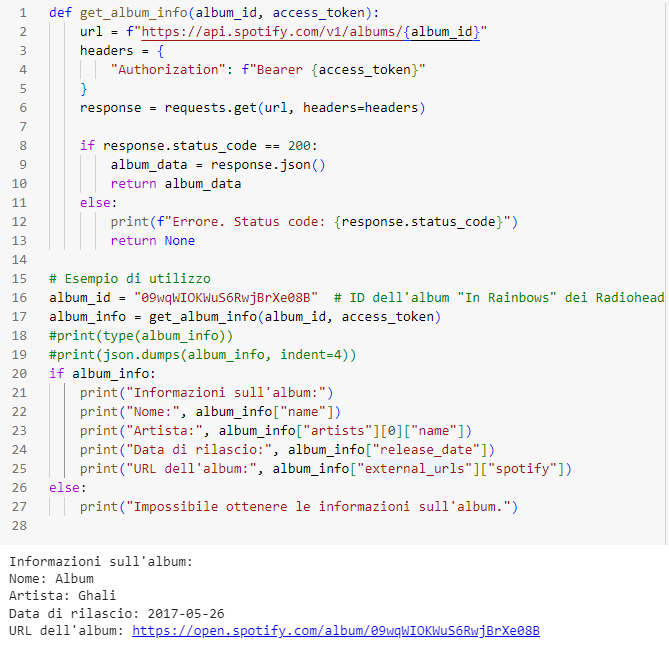

### EFFETTUARE UNA CHIAMATA (Artist info)

In [5]:
url = f"https://api.spotify.com/v1/artists/{artist_id}"
artist_id = "0OdUWJ0sBjDrqHygGUXeCF"


NameError: name 'artist_id' is not defined

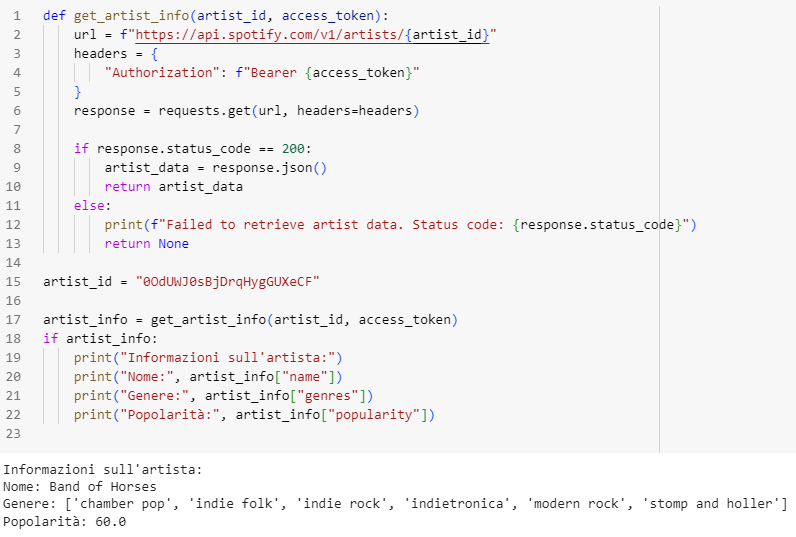

### EFFETTUARE UNA CHIAMATA (Tracce recentemente riprodotte)

In [ ]:
url = 'https://api.spotify.com/v1/me/player/recently-played'

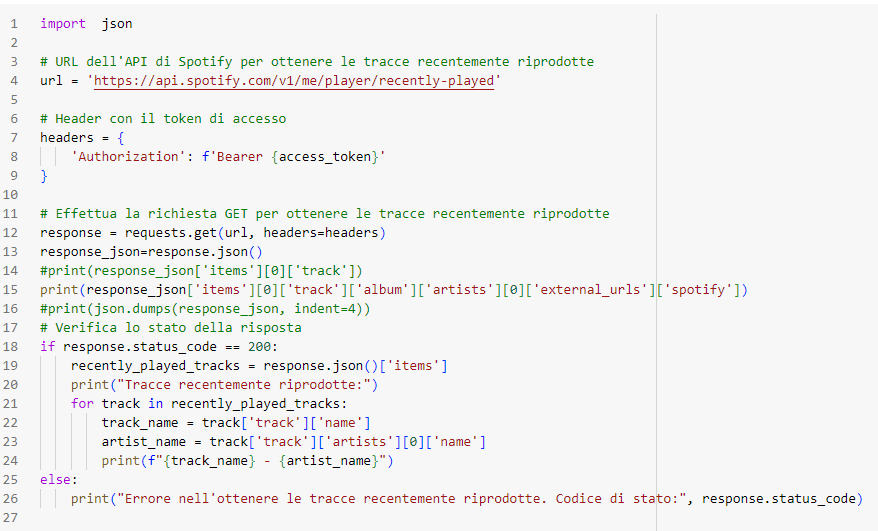

In [ ]:
response = {"my_car": {"wheels": 2,"color":"red","year":2021}}
print (response)
print(response["my_car"])
print(response["my_car"]["wheels"])
print(response["my_car"]["color"])
response["my_car"]["color"]="black"
# cosa si può dire rispetto al salvataggio di questa modifica in Django ?
print(response["my_car"]["color"])

### 5. **Installare il SDK di Spotify (opzionale)**
   Spotify offre un SDK che semplifica l'integrazione delle sue API in vari linguaggi di programmazione. Ad esempio, puoi usare il pacchetto **Spotipy** per Python per interagire con le API facilmente.

   Puoi installarlo con pip:
   ```bash
   pip install spotipy
   ```

### 6. **Fare Richieste alle API**
   Con il token di accesso, ora puoi fare richieste alle API di Spotify. Ecco alcuni esempi comuni:

#### Recuperare informazioni su un brano:
```python
import spotipy
from spotipy.oauth2 import SpotifyOAuth

# Configurazione dell'autenticazione (senza refreshing automatico del token)
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="your_client_id",
                                               client_secret="your_client_secret",
                                               redirect_uri="your_redirect_uri",
                                               scope=["user-library-read"]))

# Ottenere informazioni su un brano specifico
track = sp.track('spotify_track_id')
print(track)
```

#### Ottenere informazioni su un album:
```python
album = sp.album('spotify_album_id')
print(album)
```

#### Ottenere le playlist dell'utente:
```python
playlists = sp.current_user_playlists()
print(playlists)
```

### 7. **Gestire l'autenticazione e il refresh del token**
   I token di accesso di Spotify hanno una durata limitata. Quando il token scade, devi utilizzare il **Refresh Token** (che ottieni insieme al token di accesso) per ottenere un nuovo accesso.

```python
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="your_client_id",
                                               client_secret="your_client_secret",
                                               redirect_uri="your_redirect_uri",
                                               scope=["user-library-read"],
                                               cache_path=".cache"))
```

### 8. **Esempio di Funzionamento Completo**
   Di seguito un esempio completo che autentica l'utente, recupera i dati della sua libreria e stampa i brani salvati.

```python
import spotipy
from spotipy.oauth2 import SpotifyOAuth

sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="your_client_id",
                                               client_secret="your_client_secret",
                                               redirect_uri="your_redirect_uri",
                                               scope=["user-library-read"],
                                               cache_path=".cache")))

results = sp.current_user_saved_tracks()
for idx, item in enumerate(results['items']):
    track = item['track']
    print(f"{track['name']} - {track['artists'][0]['name']}")
```

### 9. **Consultare la Documentazione**
   La documentazione ufficiale delle API di Spotify è il miglior posto per trovare tutte le informazioni riguardanti gli endpoint, i parametri e le risposte: [Spotify Web API Documentation](https://developer.spotify.com/documentation/web-api/).

### Considerazioni Finali
- **Limiti delle API**: Spotify impone delle limitazioni sulle richieste che possono essere fatte, quindi è importante tenere traccia delle tue richieste per evitare il superamento dei limiti.
- **Sicurezza**: Non mai esporre il tuo Client Secret nel codice di produzione. Utilizza sempre variabili di ambiente o un file di configurazione sicuro.
